<a href="https://colab.research.google.com/github/Layal06-gh/IT326-Airline-Satisfaction/blob/main/phases/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1-Data Analysis

## 1- Statistic summary:

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://github.com/Layal06-gh/IT326-Airline-Satisfaction/raw/refs/heads/main/Dataset/Raw_dataset.csv')

df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


The statistical summary provides an overview of the Airline Passenger Satisfaction dataset, including mean, standard deviation, minimum, quartiles, and maximum values for numeric attributes (e.g., Age, Flight Distance, Departure Delay in Minutes, and Arrival Delay in Minutes). This summary helps us understand the data scale, detect extreme values in delay times, and identify features that require normalization or cleaning during preprocessing.

## 2. Missing Values Analysis


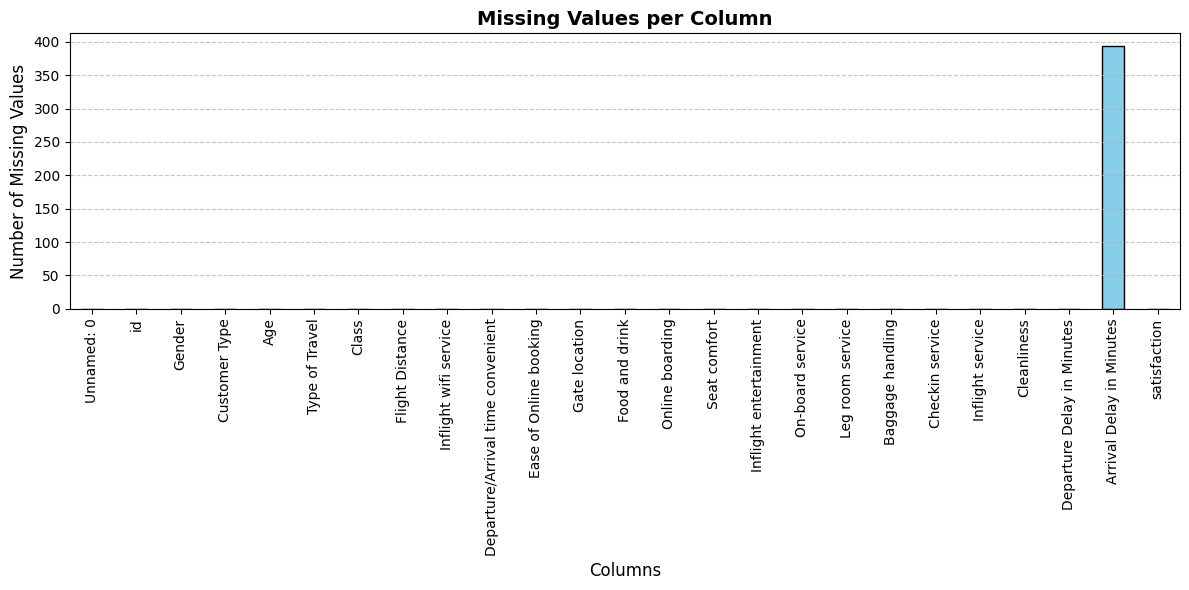

In [7]:
import matplotlib.pyplot as plt

missing_vals = df.isnull().sum()

plt.figure(figsize=(12, 6))
missing_vals.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Missing Values per Column', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The missing values analysis reveals that the dataset is clean and complete across almost all attributes, except for 'Arrival Delay in Minutes', which contains exactly 393 missing values.

Identifying these missing values directly justifies the necessity of applying an imputation technique (such as median imputation or mean imputation) during the Data Preprocessing stage to handle these 393 missing records before training classification models.


## 3. Boxplots

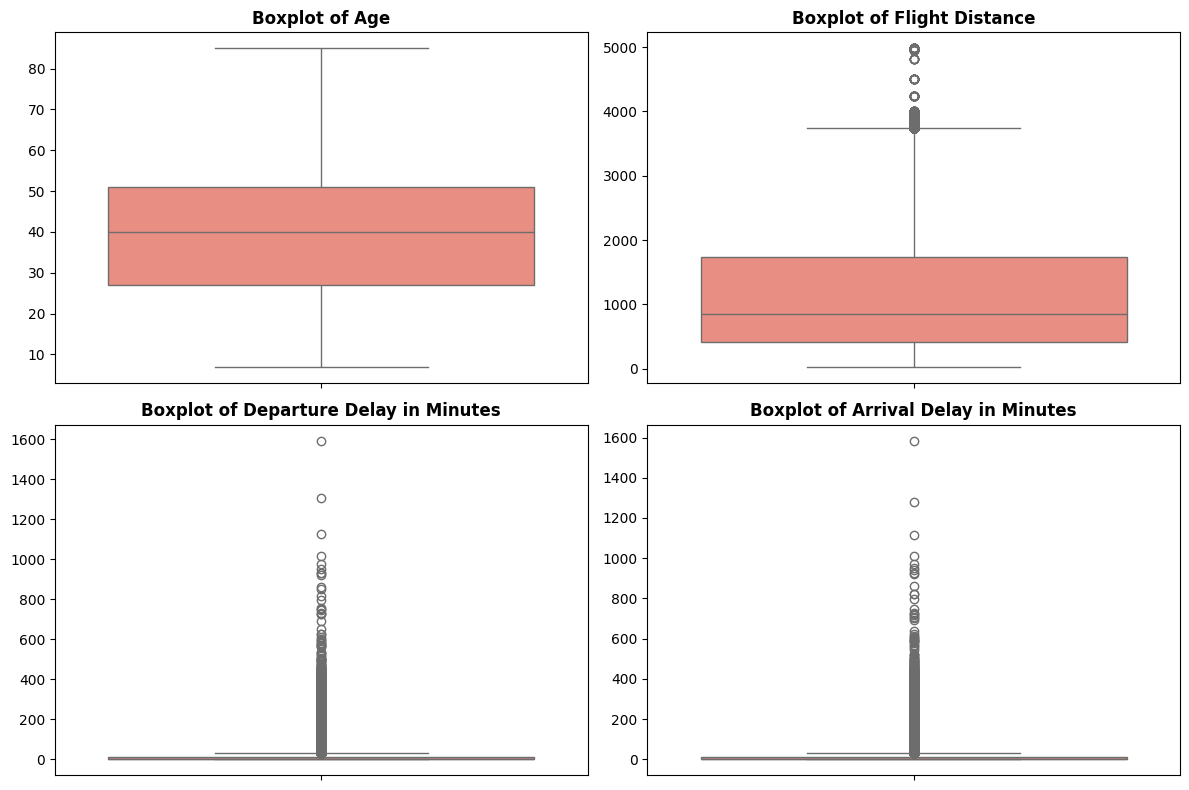

In [8]:
main_numeric_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

plt.figure(figsize=(12, 8))
for i, col in enumerate(main_numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Outlier Analysis

The boxplot analysis across key numeric features reveals the following insights:

- **Departure Delay & Arrival Delay in Minutes:** Display a heavy concentration of severe upper outliers (reaching up to 1,600 minutes). The central box appears flattened at zero because the vast majority of flights experience no delay (delay = 0 minutes), causing the first quartile (Q1), median, and third quartile (Q3) to overlap at 0. Consequently, any significant delay naturally appears as an extreme upper outlier.
- **Flight Distance:** Exhibits clear upper outliers for long-haul flight routes exceeding 4,000 units, while maintaining a well-defined interquartile box for typical short/medium-haul flights.
- **Age:** Demonstrates a clean, normally distributed profile without extreme anomalous values.